# 固定效应实操笔记

本 Notebook 配合第四章「看见之后，如何比较：固定效应在控制什么」使用。代码使用 nbstata 执行 Stata，目标是为讲义生成可复现的回归结果和图形。

核心模块包括：

- 好控制、坏控制和中介控制；
- `xtreg`、手动 de-mean 与 `reghdfe`；
- 递进 `absorb()` 如何改变比较范围；
- 处理变量被同层级固定效应吸收；
- `log(1+y)` 与 `ppmlhdfe` 的对照；
- 组内变异缩水；
- `regife` 交互固定效应。


## 模块一：好的控制变量


In [ ]:
clear all
set more off
set seed 135
set obs 30

gen Z = _n
gen X = 1*Z + rnormal()
gen Y = 1*X + 1*Z + 0.1*rnormal()

eststo clear
qui eststo m1: reg Y X
qui eststo m2: reg Y Z
qui eststo m3: reg Y X Z

esttab m1 m2 m3, nogap compress


Running D:\stata19/profile.do ...




Number of observations (_N) was 0, now 30.









-------------------------------------------------
                 (1)          (2)          (3)   
                   Y            Y            Y   
-------------------------------------------------
X              1.985***                  1.008***
             (79.98)                   (69.57)   
Z                           1.995***     0.990***
                          (78.20)      (68.02)   
_cons          0.309       0.0109       0.0245   
              (0.70)       (0.02)       (0.71)   
-------------------------------------------------
N                 30           30           30   
-------------------------------------------------
t statistics in parentheses
* p<0.05, ** p<0.01, *** p<0.001




## 模块二：坏控制：M 偏误 / collider


In [2]:
clear all
set more off
set seed 135
set obs 1000

gen X = rnormal()
gen U1 = rnormal()
gen U2 = rnormal()
gen Z = 0.7*X + 0.7*U2 + rnormal()
gen Y = 1*U2 + rnormal()

eststo clear
qui eststo m1: reg Y X
qui eststo m2: reg Y X Z
esttab m1 m2, nogap compress






Number of observations (_N) was 0, now 1,000.










------------------------------------
                 (1)          (2)   
                   Y            Y   
------------------------------------
X            -0.0381       -0.414***
             (-0.87)      (-9.06)   
Z                           0.521***
                          (16.04)   
_cons        -0.0567      -0.0406   
             (-1.28)      (-1.02)   
------------------------------------
N               1000         1000   
------------------------------------
t statistics in parentheses
* p<0.05, ** p<0.01, *** p<0.001




## 模块三：中介控制改变估计对象


In [2]:
clear all
set seed 20260706
set obs 1000

gen X = rnormal()
gen M = 0.8*X + rnormal()
gen Y = 1*X + 1*M + rnormal()

eststo clear
eststo total: reg Y X
eststo direct: reg Y X M
esttab total direct, se nogap


Number of observations (_N) was 0, now 1,000.



      Source |       SS           df       MS      Number of obs   =     1,000
-------------+----------------------------------   F(1, 998)       =   1524.20
       Model |   3345.8102         1   3345.8102   Prob > F        =    0.0000
    Residual |  2190.73017       998  2.19512041   R-squared       =    0.6043
-------------+----------------------------------   Adj R-squared   =    0.6039
       Total |  5536.54037       999  5.54208246   Root MSE        =    1.4816



------------------------------------------------------------------------------


           Y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]


-------------+----------------------------------------------------------------


...

       _cons |     -0.010      0.047    -0.22   0.823       -0.102       0.082


------------------------------------------------------------------------------



      Source |       SS           df       MS      Number of obs   =     1,000
-------------+----------------------------------   F(2, 997)       =   2039.25
       Model |  4448.97698         2  2224.48849   Prob > F        =    0.0000
    Residual |  1087.56339       997   1.0908359   R-squared       =    0.8036
-------------+----------------------------------   Adj R-squared   =    0.8032
       Total |  5536.54037       999  5.54208246   Root MSE        =    1.0444



------------------------------------------------------------------------------
           Y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
           X |      0.985      0.041    23.95   0.000        0.905       1.066
           M |      1.053      0.033    31.80   0.000        0.988       1.118
       _cons |     -0.002      0.033    -0.06   0.949       -0.067       0.063
------------------------------------------------------------------------------



--------------------------------------------
                      (1)             (2)   
                        Y               Y   
--------------------------------------------
X                   1.793***        0.985***
                 (0.0459)        (0.0411)   
M                                   1.053***
                                 (0.0331)   
_cons             -0.0105        -0.00211   
                 (0.0469)        (0.0331)   
--------------------------------------------
N                    1000            1000   
--------------------------------------------
Standard errors in parentheses
* p<0.05, ** p<0.01, *** p<0.001


## 模块四：`xtreg`、手动去心和固定效应


In [5]:
webuse nlswork, clear
xtset idcode year
keep if !missing(ln_wage, tenure, age, grade, idcode, year)

eststo clear
qui eststo pooled: reg ln_wage tenure age grade
qui eststo fe:   xtreg ln_wage tenure age grade, fe
qui eststo re:   xtreg ln_wage tenure age grade, re
qui eststo twfe: xtreg ln_wage tenure age i.year, fe

local m "pooled fe re twfe"
esttab `m', t(2) mtitle(`m') nogap drop(*.year)


(National Longitudinal Survey of Young Women, 14-24 years old in 1968)


Panel variable: idcode (unbalanced)
 Time variable: year, 68 to 88, but with gaps
         Delta: 1 unit

(435 observations deleted)








----------------------------------------------------------------------------
                      (1)             (2)             (3)             (4)   
                   pooled              fe              re            twfe   
----------------------------------------------------------------------------
tenure             0.0348***       0.0211***       0.0254***       0.0211***
                  (48.71)         (26.37)         (34.62)         (26.24)   
age               0.00622***       0.0122***       0.0103***       0.0113   
                  (15.45)         (29.52)         (27.14)          (1.11)   
grade              0.0784***            0          0.0784***                
                  (74.57)             (.)         (41.91)                   
_cons           

In [ ]:
webuse nlswork, clear
xtset idcode year
keep if !missing(ln_wage, tenure, idcode)

bysort idcode: egen mean_lnwage = mean(ln_wage)
bysort idcode: egen mean_tenure = mean(tenure)

gen dm_lnwage = ln_wage - mean_lnwage
gen dm_tenure = tenure - mean_tenure

eststo clear
qui eststo demean: reg dm_lnwage dm_tenure, nocons
qui eststo xtfe: xtreg ln_wage tenure, fe
esttab demean xtfe, t(2) nogap


(National Longitudinal Survey of Young Women, 14-24 years old in 1968)


Panel variable: idcode (unbalanced)
 Time variable: year, 68 to 88, but with gaps
         Delta: 1 unit
(433 observations deleted)



      Source |       SS           df       MS      Number of obs   =    28,101
-------------+----------------------------------   F(1, 28100)     =   3026.21
       Model |  232.253496         1  232.253496   Prob > F        =    0.0000
    Residual |  2156.60137    28,100   .07674738   R-squared       =    0.0972
-------------+----------------------------------   Adj R-squared   =    0.0972
       Total |  2388.85487    28,101  .085009604   Root MSE        =    .27703



------------------------------------------------------------------------------
   dm_lnwage | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
   dm_tenure |      0.034      0.001    55.01   0.000        0.033       0.035
------------------------------------------------------------------------------



Fixed-effects (within) regression               Number of obs     =     28,101
Group variable: idcode                          Number of groups  =      4,699

R-squared:                                      Obs per group:
     Within  = 0.0972                                         min =          1
     Between = 0.1966                                         avg =        6.0
     Overall = 0.1373                                         max =         15

                                                F(1, 23401)       =    2520.15
corr(u_i, Xb) = 0.1395                          Prob > F          =     0.0000

------------------------------------------------------------------------------
     ln_wage | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      tenure |      0.034      0.001    50.20   0.000        0.033       0.036
       _cons |      1.570      0.003   562.14   0.000        1.5


--------------------------------------------
                      (1)             (2)   
                dm_lnwage         ln_wage   
--------------------------------------------
dm_tenure          0.0342***                
               (0.000621)                   
tenure                             0.0342***
                               (0.000681)   
_cons                               1.570***
                                (0.00279)   
--------------------------------------------
N                   28101           28101   
--------------------------------------------
Standard errors in parentheses
* p<0.05, ** p<0.01, *** p<0.001


## 模块五：递进 `absorb()` 和比较范围


In [ ]:
cap which reghdfe
if _rc {
    ssc install ftools, replace
    ssc install reghdfe, replace
}

qui{
    clear all
    set seed 20260706
    set obs 3000
    
    gen firm = ceil(_n/10)
    bysort firm: gen year = 2000 + _n
    gen industry = ceil(firm/30)
    
    gen alpha = rnormal()
    bysort firm: replace alpha = alpha[1]
    gen lambda = 0.1*(year-2000)
    gen indshock = rnormal()
    bysort industry year: replace indshock = indshock[1]
    
    gen x = 0.5*alpha + 0.3*indshock + rnormal()
    gen y = 1*x + alpha + lambda + indshock + rnormal()
    
    eststo clear
    eststo pols: reg     y x
    eststo fe:   reghdfe y x, absorb(firm)
    eststo twfe: reghdfe y x, absorb(firm year)
    eststo hdfe: reghdfe y x, absorb(firm year industry#year)
}

local m "pols fe twfe hdfe"
esttab `m', mtitle(`m') t(2) nogap







----------------------------------------------------------------------------
                      (1)             (2)             (3)             (4)   
                     pols              fe            twfe            hdfe   
----------------------------------------------------------------------------
x                   1.596***        1.306***        1.281***        0.987***
                  (62.41)         (48.83)         (49.83)         (50.82)   
_cons               0.671***        0.679***        0.680***        0.688***
                  (22.67)         (25.44)         (26.64)         (37.77)   
----------------------------------------------------------------------------
N                    3000            3000            3000            3000   
----------------------------------------------------------------------------
t statistics in parentheses
* p<0.05, ** p<0.01, *** p<0.001




## 模块六：处理变量被同层级固定效应吸收


In [6]:
clear all
set seed 20260706
set obs 3000

gen firm = ceil(_n/10)
bysort firm: gen year = 2000 + _n
gen industry = ceil(firm/30)

gen treat_ind_year = (industry <= 10 & year >= 2005)
gen y = 1*treat_ind_year + rnormal()

cap which reghdfe
if _rc {
    ssc install ftools, replace
    ssc install reghdfe, replace
}

reghdfe y treat_ind_year, absorb(firm year)
reghdfe y treat_ind_year, absorb(firm year industry#year)


Number of observations (_N) was 0, now 3,000.


(MWFE estimator converged in 2 iterations)
note: treat_ind_year is probably collinear with the fixed effects (all partiall
> ed-out values are close to zero; tol = 1.0e-09)



HDFE Linear regression                            Number of obs   =      3,000
Absorbing 2 HDFE groups                           F(   0,   2691) =          .
                                                  Prob > F        =          .
                                                  R-squared       =     0.2713
                                                  Adj R-squared   =     0.1879
                                                  Within R-sq.    =     0.0000
                                                  Root MSE        =     1.0327



------------------------------------------------------------------------------


           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]


...

-----------------------------------------------------+
 Absorbed FE | Categories  - Redundant  = Num. Coefs |


-------------+---------------------------------------|
        firm |       300           0         300     |


        year |        10           1           9     |
-----------------------------------------------------+


(MWFE estimator converged in 2 iterations)
note: treat_ind_year is probably collinear with the fixed effects (all partiall
> ed-out values are close to zero; tol = 1.0e-09)

HDFE Linear regression                            Number of obs   =      3,000
Absorbing 3 HDFE groups                           F(   0,   2601) =          .
                                                  Prob > F        =          .
                                                  R-squared       =     0.2927
                                                  Adj R-squared   =     0.1845
                                                  Within R-sq.    =     0.0000
                                                  Root MSE        =     1.0349

------------------------------------------------------------------------------
           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
treat_ind_~r |      0.000  (omitted


Absorbed degrees of freedom:
---------------------------------------------------------+
     Absorbed FE | Categories  - Redundant  = Num. Coefs |
-----------------+---------------------------------------|
            firm |       300           0         300     |
            year |        10           1           9     |
   industry#year |       100          10          90    ?|
---------------------------------------------------------+
? = number of redundant parameters may be higher


## 模块七：`log(1+y)` 与 `ppmlhdfe`


In [7]:
cap which ppmlhdfe
if _rc {
    ssc install ppmlhdfe, replace
}

clear all
set seed 20260706
set obs 5000

gen firm = ceil(_n/10)
bysort firm: gen year = 2000 + _n

gen alpha = rnormal()
bysort firm: replace alpha = alpha[1]
gen x = rnormal()

gen mu = exp(0.5*x + 0.5*alpha)
gen y = rpoisson(mu)

replace y = 0 if runiform() < 0.35

gen ln1y = ln(1+y)

eststo clear
eststo log1: reghdfe ln1y x, absorb(firm year) vce(cluster firm)
eststo ppml: ppmlhdfe y x, absorb(firm year) vce(cluster firm) nolog
esttab log1 ppml, se nogap




Number of observations (_N) was 0, now 5,000.




(4500 real changes made)




(1,152 real changes made)



(MWFE estimator converged in 2 iterations)

HDFE Linear regression                            Number of obs   =      5,000
Absorbing 2 HDFE groups                           F(   1,    499) =     369.25
Statistics robust to heteroskedasticity           Prob > F        =     0.0000
                                                  R-squared       =     0.2433
                                                  Adj R-squared   =     0.1575
                                                  Within R-sq.    =     0.0941
Number of clusters (firm)    =        500         Root MSE        =     0.5091

                                 (Std. err. adjusted for 500 clusters in firm)
------------------------------------------------------------------------------
             |               Robust
        ln1y | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+-----

## 模块八：慢变量和组内变异缩水


Number of observations (_N) was 0, now 1,000.
(900 real changes made)



Panel variable: id (strongly balanced)
 Time variable: year, 2001 to 2010
         Delta: 1 unit

Variable         |      Mean   Std. dev.       Min        Max |    Observations
-----------------+--------------------------------------------+----------------
x_slow   overall |  .0474712   .9204853  -2.754302   1.984801 |     N =    1000
         between |             .9214389  -2.590049   1.800181 |     n =     100
         within  |             .0767637  -.2010264   .2491974 |     T =      10



      Source |       SS           df       MS      Number of obs   =     1,000
-------------+----------------------------------   F(1, 998)       =   2882.45
       Model |   3155.0743         1   3155.0743   Prob > F        =    0.0000
    Residual |  1092.39108       998  1.09458024   R-squared       =    0.7428
-------------+----------------------------------   Adj R-squared   =    0.7426
       Total |  4247.46538       999   4.2517171   Root MSE        =    1.0462



------------------------------------------------------------------------------


           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]


...


Fixed-effects (within) regression               Number of obs     =      1,000
Group variable: id                              Number of groups  =        100

R-squared:                                      Obs per group:
     Within  = 0.0067                                         min =         10
     Between = 0.9719                                         avg =       10.0
     Overall = 0.7428                                         max =         10

                                                F(1, 899)         =       6.05
corr(u_i, Xb) = 0.9319                          Prob > F          =     0.0141

------------------------------------------------------------------------------
           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      x_slow |      1.067      0.434     2.46   0.014        0.215       1.919
       _cons |     -0.069      0.039    -1.76   0.079       -0.1

--------------------------------------------
                      (1)             (2)   
                        y               y   
--------------------------------------------
x_slow              1.931***        1.067*  
                 (0.0360)         (0.434)   
_cons              -0.110***      -0.0689   
                 (0.0331)        (0.0392)   
--------------------------------------------
N                    1000            1000   
--------------------------------------------
Standard errors in parentheses
* p<0.05, ** p<0.01, *** p<0.001
(bin=29, start=-2.7543017, width=.16341735)


(bin=29, start=-.24849761, width=.01552496)


(file notebooks/ch04_fixed_effects/fig_within_variation_s
> hrinkage.png not found)


file notebooks/ch04_fixed_effects/fig_within_variation_sh
> rinkage.png written in PNG format


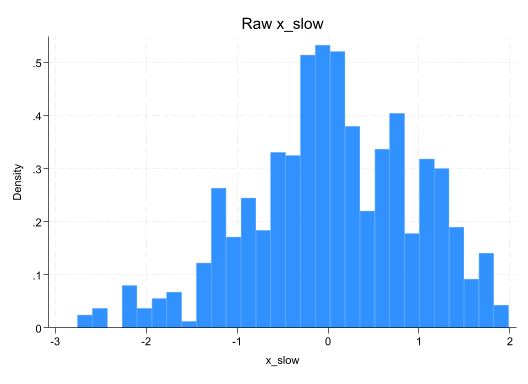

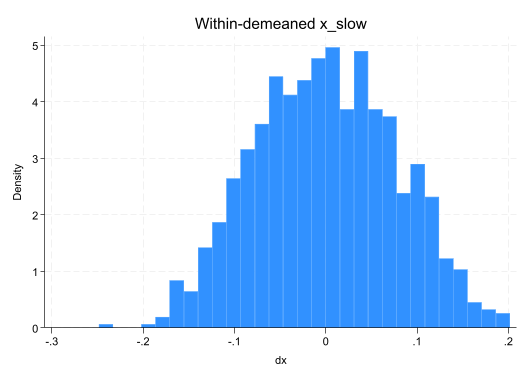

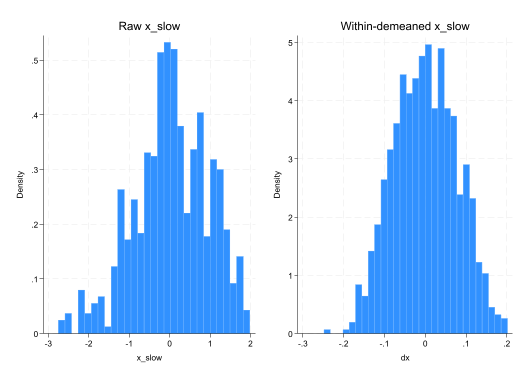

In [8]:
clear all
set seed 20260706
set obs 1000

gen id = ceil(_n/10)
bysort id: gen year = 2000 + _n

gen alpha = rnormal()
bysort id: replace alpha = alpha[1]

gen x_slow = alpha + 0.02*(year-2000) + rnormal()*0.05
gen y = 1*x_slow + alpha + rnormal()

xtset id year
xtsum x_slow

eststo clear
eststo pooled: reg y x_slow
eststo fe: xtreg y x_slow, fe
esttab pooled fe, se nogap

bysort id: egen mx = mean(x_slow)
gen dx = x_slow - mx

histogram x_slow, name(rawx, replace) title("Raw x_slow")
histogram dx, name(dmx, replace) title("Within-demeaned x_slow")
graph combine rawx dmx, col(2)
graph export "notebooks/ch04_fixed_effects/fig_within_variation_shrinkage.png", width(1200) replace


## 模块九：Mundlak / CRE 思路


In [9]:
webuse nlswork, clear
xtset idcode year
keep if !missing(ln_wage, tenure, age, grade, idcode)

bysort idcode: egen mean_tenure = mean(tenure)
bysort idcode: egen mean_age = mean(age)

xtreg ln_wage tenure age mean_tenure mean_age grade, re vce(cluster idcode)


(National Longitudinal Survey of Young Women, 14-24 years old in 1968)


Panel variable: idcode (unbalanced)
 Time variable: year, 68 to 88, but with gaps
         Delta: 1 unit


(435 observations deleted)



Random-effects GLS regression                   Number of obs     =     28,099
Group variable: idcode                          Number of groups  =      4,697

R-squared:                                      Obs per group:
     Within  = 0.1296                                         min =          1
     Between = 0.4073                                         avg =        6.0
     Overall = 0.3016                                         max =         15

                                                Wald chi2(5)      =    4064.86
corr(u_i, X) = 0 (assumed)                      Prob > chi2       =     0.0000

                             (Std. err. adjusted for 4,697 clusters in idcode)
------------------------------------------------------------------------------
             |               Robust
     ln_wage | Coefficient  std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
      tenure |

      0.021      0.001    17.45   0.000        0.019       0.024
         age |      0.012      0.001    16.45   0.000        0.011       0.014
 mean_tenure |      0.025      0.002    11.24   0.000        0.021       0.029
    mean_age |     -0.010      0.001    -8.42   0.000       -0.013      -0.008
       grade |      0.078      0.002    35.46   0.000        0.074       0.082
       _cons |      0.488      0.033    14.66   0.000        0.423       0.554
-------------+----------------------------------------------------------------
     sigma_u |  .28278414
     sigma_e |  .29808194
         rho |  .47368207   (fraction of variance due to u_i)
------------------------------------------------------------------------------


## 模块十：`regife` 交互固定效应


In [10]:
cap which regife
if _rc {
    di as error "regife not installed. Please install or verify the command source before running this module."
}
else {
    webuse nlswork, clear
    keep if idcode <= 100
    xtset idcode year

    eststo clear
    eststo fe: xtreg ln_wage tenure, fe
    eststo twfe: xtreg ln_wage tenure i.year, fe

    regife ln_wage tenure, absorb(idcode year) ife(idcode year, 1)
    eststo intfe

    esttab fe twfe intfe, drop(*.year) nogap
}


(National Longitudinal Survey of Young Women, 14-24 years old in 1968)
(27,956 observations deleted)

Panel variable: idcode (unbalanced)
 Time variable: year, 68 to 88, but with gaps
         Delta: 1 unit



Fixed-effects (within) regression               Number of obs     =        570
Group variable: idcode                          Number of groups  =         90

R-squared:                                      Obs per group:
     Within  = 0.1302                                         min =          1
     Between = 0.1853                                         avg =        6.3
     Overall = 0.1084                                         max =         15

                                                F(1, 479)         =      71.71
corr(u_i, Xb) = 0.0528                          Prob > F          =     0.0000



------------------------------------------------------------------------------
     ln_wage | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      tenure |      0.039      0.005     8.47   0.000        0.030       0.049
       _cons |      1.755      0.018    99.41   0.000        1.720       1.790
-------------+----------------------------------------------------------------
     sigma_u |  .35796302
     sigma_e |  .27590074
         rho |  .62732945   (fraction of variance due to u_i)
------------------------------------------------------------------------------
F test that all u_i=0: F(89, 479) = 9.80                     Prob > F = 0.0000



Fixed-effects (within) regression               Number of obs     =        570
Group variable: idcode                          Number of groups  =         90

R-squared:                                      Obs per group:
     Within  = 0.1959                                         min =          1
     Between = 0.1574                                         avg =        6.3
     Overall = 0.1493                                         max =         15

                                                F(15, 465)        =       7.55
corr(u_i, Xb) = 0.0845                          Prob > F          =     0.0000

------------------------------------------------------------------------------
     ln_wage | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      tenure |      0.026      0.006     4.65   0.000        0.015       0.037
             |
        year |
         69  |

      0.108      0.073     1.47   0.143       -0.037       0.252
         70  |      0.080      0.067     1.19   0.233       -0.052       0.213
         71  |      0.104      0.068     1.54   0.124       -0.029       0.237
         72  |      0.043      0.070     0.62   0.536       -0.094       0.181
         73  |      0.099      0.070     1.41   0.158       -0.039       0.237
         75  |      0.137      0.070     1.96   0.050       -0.000       0.274
         77  |      0.192      0.072     2.68   0.008        0.051       0.332
         78  |      0.169      0.077     2.20   0.028        0.018       0.321
         80  |      0.057      0.079     0.72   0.473       -0.099       0.213
         82  |      0.125      0.077     1.63   0.104       -0.026       0.275
         83  |      0.158      0.078     2.03   0.043        0.005       0.310
         85  |      0.219      0.079     2.78   0.006        0.064       0.374
         87  |      0.272      0.074     3.66   0.000        0.126


REGIFE                                            Number of obs   =        561
Panel structure: idcode, year                     F(   1,    369) =       4.08
Factor dimension: 1                               Prob > F        =     0.0441
Converged: true                                   Root MSE        =     0.2194
                                                  Iterations      =        254
------------------------------------------------------------------------------
     ln_wage | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      tenure |      0.012      0.006     2.02   0.044        0.000       0.023
       _cons |      1.837      0.019    94.79   0.000        1.798       1.875
------------------------------------------------------------------------------



------------------------------------------------------------
                      (1)             (2)             (3)   
                  ln_wage         ln_wage         ln_wage   
------------------------------------------------------------
tenure             0.0394***       0.0258***       0.0118*  
                   (8.47)          (4.65)          (2.02)   
_cons               1.755***        1.649***        1.837***
                  (99.41)         (30.68)         (94.79)   
------------------------------------------------------------
N                     570             570             561   
------------------------------------------------------------
t statistics in parentheses
* p<0.05, ** p<0.01, *** p<0.001
